# modeling non-linear patterns w/ activation functions

our previous simple linear model performed well on bike-only data, but it struggled when cars were added. the reason was simple: the model could only learn **straight lines**, but the new data followed a **curve**. As you saw in the lectures, simply adding more linear neurons is not the solution. The model's output would still be a straight line.

**non-linear activation functions** come in and are meant to unlock the model's ability to learn the complex, curved patterns found in real-world data. we will use **ReLU (Rectified Linear Unit)**, to allow us to create multiple "bends" that can approximate the complex delivery time curve.

### rubric + context:

* prepare the combined bike and car delivery data, this time applying a technique called **normalization** to help model train more effectively.
* build a *non-linear* neural network using the **ReLU** activation function.
* train new model to learn the complex, curved relationship in the data.
* predict delivery times using the new model and see if it can finally succeed where the linear one failed.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils_new as helper_utils

## prepping non-linear data

load the same dataset that caused problems at the end of the last lab. 
> this is the combined data for both bike and car deliveries.

### input tensors:

In [3]:
# dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

* you will see from running the code below, the data plot follows a non-linear pattern.

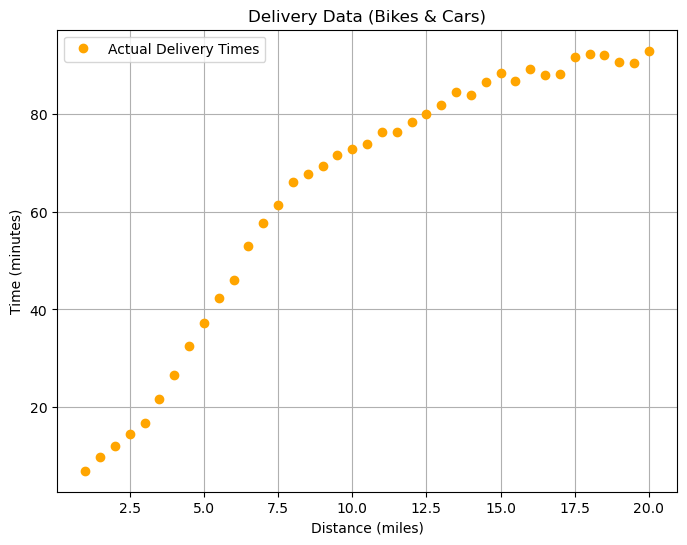

In [4]:
helper_utils.plot_data(distances, times)

### step: normalizing the data

this is a data preparation step called **normalization**. this is a standard technique that makes the training process more stable and effective by adjusting the scale of the data. this adjustment helps prevent large distance values from dominating the learning process and keeps gradients stable during training.

* compute the mean and standard deviation for the `distances` and `times` tensors.
* apply standardization to each tensor using its respective mean and standard deviation, which creates new normalized tensors named `distances_norm` and `times_norm`.
* this specific technique is called **standardization** (or z-score normalization), which converts the original data from `1.0 to 20.0 miles` and approximately `7 to 93 minutes` into a new, normalized scale.

In [5]:
# the mean and standard deviation for the 'distances' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# apply standardization to the distances.
distances_norm = (distances - distances_mean) / distances_std

# apply standardization to the times.
times_norm = (times - times_mean) / times_std

* notice the axes now show the data on a new, normalized scale, with distance ranging from approximately `-1.7 to 1.7` and time from `-2.0 to 1.0`.
* the underlying curved pattern of the data remains exactly the same, regardless of this change in scale.

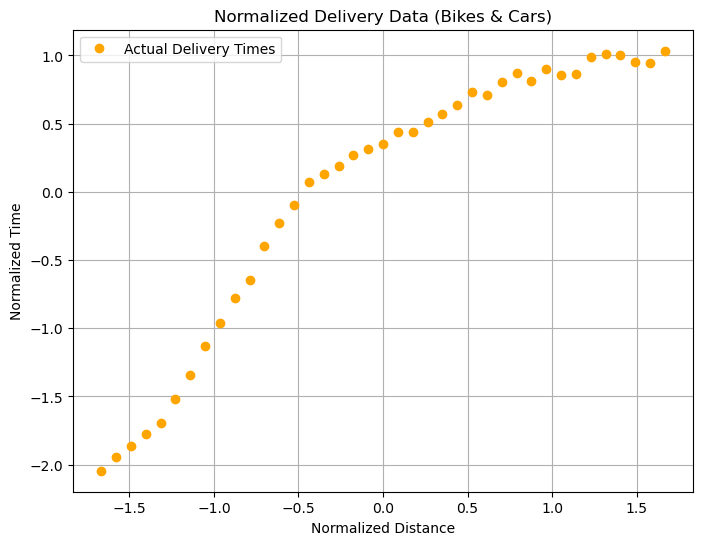

In [6]:
helper_utils.plot_data(distances_norm, times_norm, normalize=True)

## the non-linear model

this will use the normalized data, and the model should be capable of learning its curved pattern. this means we define the model's architecture, which now includes a `ReLU` activation function. this structure is what gives the model the ability to learn non-linear relationships.

* `nn.Linear(1, 3)`: this is the **first hidden layer**. it consists of three neurons, each receiving one input feature (the normalized distance). this layer transforms the single input value into three separate values.
* `nn.ReLU()` applies the ReLU activation function to the output of each of the three neurons from the hidden layer. this is the crucial non-linear step that allows the model to create "bends" and learn curves instead of just straight lines.
* `nn.Linear(3, 1)`: this is the **output layer**. it takes the three activated values from the previous step as its input and combines them to produce a single final output, which is the predicted (normalized) delivery time.

> **NOTE**: this creates a neural network with 1 hidden layer containing 3 neurons.

In [7]:
# seed for reproducability and consistencyy.
torch.manual_seed(27)

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

## training

* we use a MSELoss loss function and the sdg optimizer for training.

In [8]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

* run the training loop for `3000` epochs (this is relatively large because the non-linear pattern is more complex and requires more training). this will repeatedly feed the *normalized* data to the model, measure the error, and adjust the model's parameters to improve its predictions.
* the second half of the code includes a live plot, allowing watching in real time as the model's prediction line adapts to fit the curved data. the live plot helps you see how the model gradually learns to fit the curve, starting with a poor fit and improving over time.

**IMPORTANT NOTE**: as the plot updates in real time during training, you might notice a flickering effect. This is the expected behavior of the live visualization and not an issue with your screen.

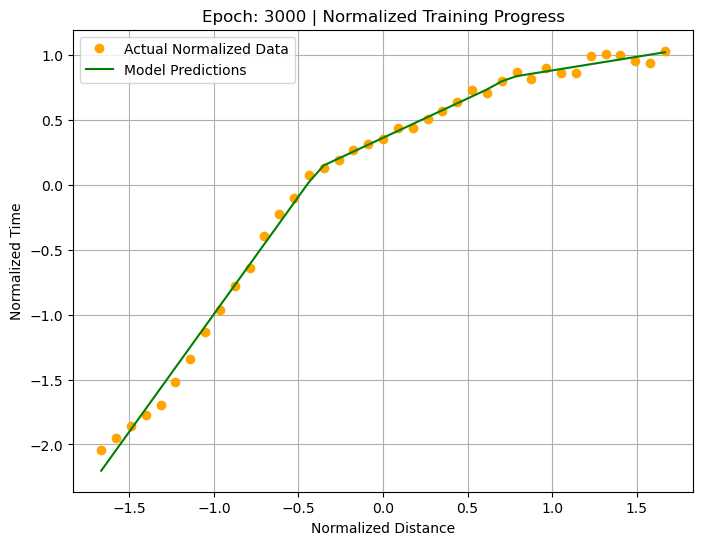


training complete.

final loss: 0.0029688039794564247


In [10]:
# training loop
for epoch in range(3000):
    # reset the optimizer's gradients
    optimizer.zero_grad()
    # make predictions (forward pass)
    outputs = model(distances_norm)
    # loss
    loss = loss_function(outputs, times_norm)
    # calculate adjustments (backward pass)
    loss.backward()
    # update the model's parameters
    optimizer.step()

    # create a live plot every 50 epochs
    if (epoch + 1) % 50 == 0:
        helper_utils.plot_training_progress(
            epoch=epoch,
            loss=loss,
            model=model,
            distances_norm=distances_norm,
            times_norm=times_norm
        )

print("\ntraining complete.")
print(f"\nfinal loss: {loss.item()}")

## final fit 

training is complete, and you could visualize the result.

* plot your model's final predicted curve against the original data points.
  > this lets you visually inspect how well your non-linear model learned to fit the complex data pattern.

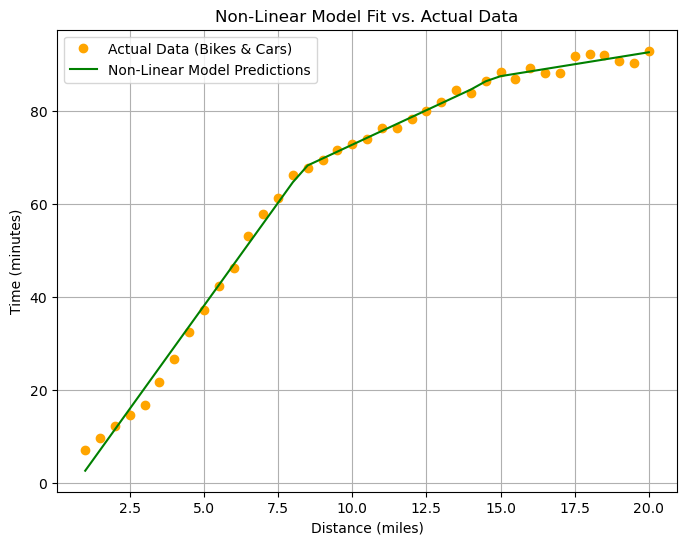

In [11]:
helper_utils.plot_final_fit(model, distances, times, distances_norm, times_std, times_mean)

<br>

from the plot:  
the **non-linear** neural network model with a `ReLU` activation function succeeded; where the linear model failed. the model learned to capture the complex, curved relationship in the combined bike and car delivery data.

## prediction
w/ a fully trained non-linear model, you can now use it to make a prediction for a new delivery. the process is slightly different now because your model was trained on *normalized* data.

* first, you will take the new input distance and **normalize** it using the same mean and standard deviation from your training data. this step is CRITICAL: the model has no idea about the original scales (miles and minutes). it only understands the normalized scale it was trained on.
* after the model provides its prediction, you must **de-normalize** the output. this converts the prediction from its normalized scale back into an understandable value in minutes.
* finally, the code uses this actual predicted time to run the decision logic. for this prediction, assume your company now promises deliveries within 45 minutes (instead of 30 minutes) and wants to know which vehicle to use.

In [12]:
distance_to_predict = 5.1

In [14]:
# use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
    # normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std
    
    # get the normalized prediction from the model
    predicted_time_norm = model(new_distance_norm)
    
    # de-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    
    # --- decision Making Logic ---
    print(f"prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")
    
    # first, check if the delivery is possible within the 45-minute timeframe
    if predicted_time_actual.item() > 45:
        print("\nDECISION: DO NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\ndecision: yes, delivery is possible. since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\ndecision: yes, delivery is possible. since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

prediction for a 5.1-mile delivery: 38.9 minutes

decision: yes, delivery is possible. since the distance is 5.1 miles (> 3 miles), use a car.


## wraps:

we saw firsthand how adding a non-linear activation function like **ReLU** gives a model the ability to succeed where a linear model fails.